In [1]:
from qiskit import QuantumCircuit

---

## quantum circuits
This is the core arguments:

`qiskit.circuit.QuantumCircuit(*regs, name=None, global_phase=0, metadata=None, inputs=(), captures=(), declarations=())`

In [4]:
qc = QuantumCircuit(1)
qc.h(0)

In [7]:
qc.draw()

┌───┐
q: ┤ H ├
   └───┘

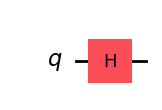

In [8]:
qc.draw("mpl")

---

### 2 bit version of the quantum circuits

In [ ]:
# Create a new circuit with two qubits
qc = QuantumCircuit(2)
 
# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
qc.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

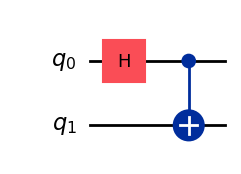

In [3]:
qc.draw("mpl") # requires pylatexenc

---

## 2 and more qubits with 2 and more classic bits:

`QuantumCircuit(2, 2)`: We create a circuit with 2 quantum bits (qubits) to operate on and 2 classical bits to store the measurement results.

    The first argument (2) is the number of qubits.
    The second argument (2) is the number of classical bits.

Qubits are for performing quantum operations (like h and cx). Classical bits are for storing the results of measurements. When you measure a qubit, its quantum state collapses to a classical 0 or 1, and you need a classical bit to save that outcome.

In [22]:
# Create a quantum circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)


It would also make sence if there are less classic bits than the qubits, You only need as many classical bits as the number of qubits you intend to measure.
For example, you could have a circuit with 5 qubits but only measure 2 of them.
```python
# A circuit with 5 qubits and only 2 classical bits
qc = QuantumCircuit(5, 2)

# ... some quantum operations on all 5 qubits ...

# We only measure qubit 0 and qubit 4
# The result from qubit 0 is stored in classical bit 0
# The result from qubit 4 is stored in classical bit 1
qc.measure([0, 4], [0, 1])
```

In [47]:
# Create a circuit with 5 qubits and 5 classical bits
qc = QuantumCircuit(5, 5)

# 1. Apply a gate to the first qubit (index 0)
qc.h(0)

# 2. Apply a gate to the third qubit (index 2)
qc.x(2) # An X-gate is the quantum equivalent of a NOT gate

# 3. Entangle the last two qubits (index 3 and 4)
# Use qubit 3 as the control and qubit 4 as the target
qc.cx(3, 4)


### qubit measurments: Why Do You Need Classical Bits

To store the results of a measurement.

A qubit's quantum state is fragile. The moment you measure it, its superposition collapses into a definite 0 or 1. The classical bit is like a standard computer bit (a tiny piece of memory) that "catches" and stores that outcome.


In [50]:
# For example, measure qubits 0, 2, and 4 and store the results
# in classical bits 0, 1, and 2.
qc.measure([0, 2, 4], [0, 1, 2])

qc.draw()

┌───┐┌─┐      
q_0: ┤ H ├┤M├──────
     └───┘└╥┘      
q_1: ──────╫───────
     ┌───┐ ║ ┌─┐   
q_2: ┤ X ├─╫─┤M├───
     └───┘ ║ └╥┘   
q_3: ──■───╫──╫────
     ┌─┴─┐ ║  ║ ┌─┐
q_4: ┤ X ├─╫──╫─┤M├
     └───┘ ║  ║ └╥┘
c: 5/══════╩══╩══╩═
           0  1  2

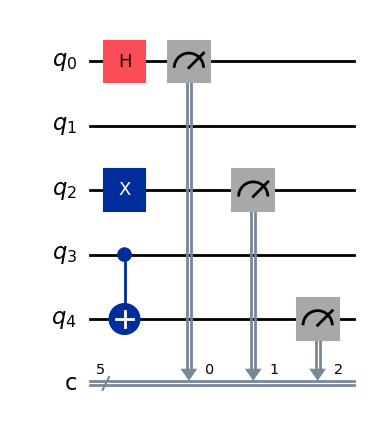

In [52]:
qc.draw('mpl')

### A full example so far:

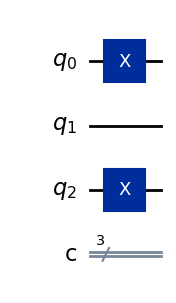

In [67]:
qc = QuantumCircuit(3, 3)

# By default, all qubits start in the |0> state.
# Let's flip qubit 0 and qubit 2 to create the state |101>.
# (Remember, qubit order is q2, q1, q0)
qc.x(0) # Flips q0 from |0> to |1>
# q1 is already |0>, so we do nothing to it.
qc.x(2) # Flips q2 from |0> to |1>

qc.draw('mpl')


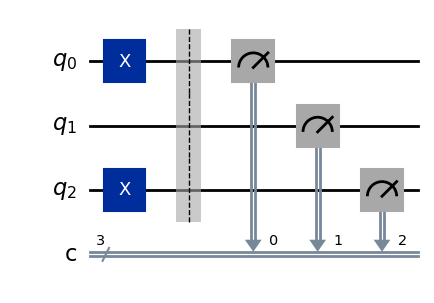

In [69]:
# Add a barrier for visual separation
qc.barrier()

# Measure all three qubits into their corresponding classical bits
# q0 -> c0, q1 -> c1, q2 -> c2
qc.measure([0, 1, 2], [0, 1, 2])

qc.draw('mpl')